<a href="https://colab.research.google.com/github/Dalton115/MAT-422/blob/main/HW2_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HW2.3   2.3.1 - 2.3.3

* Used Gemini as a study aid and coding partner to clarify probability definitions, debug python code, and format LaTex formulas.
__________________________________________________________________

1. Join Probability Distributuions (2.3.1)
2. Correlation and Dependence (2.3.2)
3. Random Samples(2.2.3)

__________________________________________________________________

# Joint Probability Distributions (2.3.1)

Key Concept (Explained and given python example):

* For tracking two discrete variables, say $X$ and $Y$, Joint Probability Mass Function (PMF) $p(x, y) = P(X = x, Y = y)$ gives the probablity of both values occurring simultaneously.
* For continuous variables, we can define with a joint PDF $f(x, y) \ge 0$, where $P((X,Y) \in A)$ represents the 3D volume under $f(x, y)$ above region $A$. Integrating out one variable yields the marginal PDF ($f_X(x) = \int_{-\infty}^{\infty} f(x, y) \, dy$).
* For independence, two variables are dependent iff their joint distribution factors into the product of their marginal distributions ($p(x, y) = p_X(x) \cdot p_Y(y)$ or $f(x, y) = f_X(x) \cdot f_Y(y)$ for all $x, y$).



SECTION 2.3.1.1: DISCRETE JOINT PMF & MARGINALS

--- Joint PMF Table with Marginals ---
            Y=1 (Low)  Y=2 (Med)  Y=3 (High)  p_X(x)
X=1 (Low)        0.10       0.05        0.02    0.17
X=2 (Med)        0.08       0.20        0.10    0.38
X=3 (High)       0.02       0.15        0.28    0.45
p_Y(y)           0.20       0.40        0.40    1.00

Total Discrete Probability Sum: 1.0000


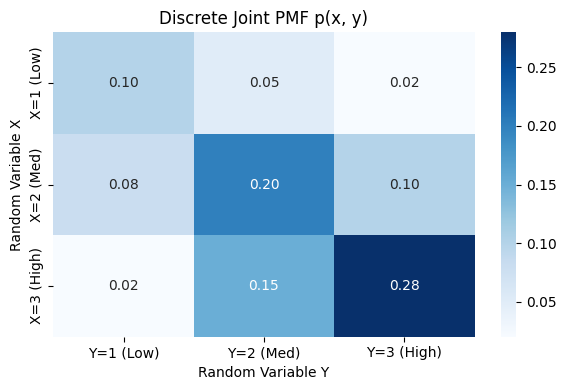


SECTION 2.3.1.2: TWO CONTINUOUS RANDOM VARIABLES

Total Volume ∫∫ f(x,y) dx dy = 1.000000
P(0.5 <= X <= 1, 0 <= Y <= 0.5) = 0.250000


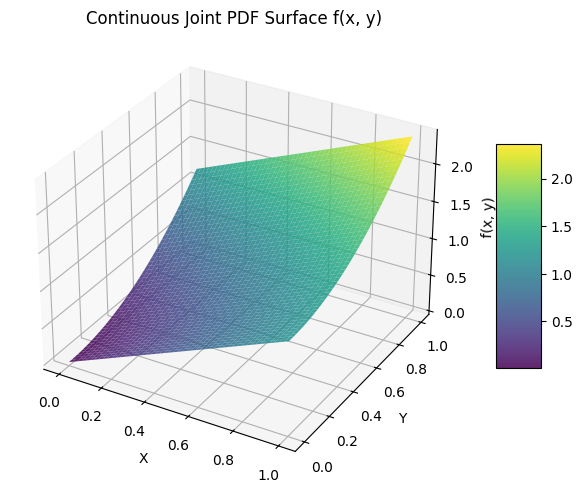


SECTION 2.3.1.3: INDEPENDENT EXPONENTIAL LIFETIMES

P(X1 >= 1400) = 0.2801
P(X2 >= 1400) = 0.3406
P(Both >= 1400) [Product Rule] = 0.0954
P(Both >= 1400) [Numerical Integration] = 0.0954


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.integrate as integrate

# ==============================================================================
# SECTION 2.3.1.1: DISCRETE JOINT PMF & MARGINALS
# ==============================================================================
print("=" * 60)
print("SECTION 2.3.1.1: DISCRETE JOINT PMF & MARGINALS")
print("=" * 60)

# 1. Define Joint PMF Matrix (X = Study Hours, Y = Exam Score Tier)
pmf_data = np.array([
    [0.10, 0.05, 0.02],
    [0.08, 0.20, 0.10],
    [0.02, 0.15, 0.28]
])

# 2. Build Pandas DataFrame
df_pmf = pd.DataFrame(
    pmf_data,
    index=['X=1 (Low)', 'X=2 (Med)', 'X=3 (High)'],
    columns=['Y=1 (Low)', 'Y=2 (Med)', 'Y=3 (High)']
)

# 3. Compute Marginals
marginal_X = df_pmf.sum(axis=1)  # Row sums -> p_X(x)
marginal_Y = df_pmf.sum(axis=0)  # Column sums -> p_Y(y)

# Format table for visual output
df_display = df_pmf.copy()
df_display['p_X(x)'] = marginal_X
df_display.loc['p_Y(y)'] = list(marginal_Y) + [df_pmf.values.sum()]

print("\n--- Joint PMF Table with Marginals ---")
print(df_display.round(2))

total_discrete_prob = np.sum(pmf_data)
print(f"\nTotal Discrete Probability Sum: {total_discrete_prob:.4f}")

# Heatmap Visualization
plt.figure(figsize=(6, 4))
sns.heatmap(df_pmf, annot=True, cmap="Blues", fmt=".2f", cbar=True)
plt.title("Discrete Joint PMF p(x, y)")
plt.xlabel("Random Variable Y")
plt.ylabel("Random Variable X")
plt.tight_layout()
plt.show()

# ==============================================================================
# SECTION 2.3.1.2: TWO CONTINUOUS RANDOM VARIABLES & 3D SURFACE
# ==============================================================================
print("\n" + "=" * 60)
print("SECTION 2.3.1.2: TWO CONTINUOUS RANDOM VARIABLES")
print("=" * 60)

# Define continuous joint PDF f(x, y) = 6/5 * (x + y^2) on [0,1] x [0,1]
def joint_pdf(y, x):
    if 0 <= x <= 1 and 0 <= y <= 1:
        return (6/5) * (x + y**2)
    return 0.0

# Verify total probability over unit square = 1
total_cont_prob, _ = integrate.dblquad(joint_pdf, 0, 1, lambda x: 0, lambda x: 1)
print(f"\nTotal Volume ∫∫ f(x,y) dx dy = {total_cont_prob:.6f}")

# Compute probability over region A: [0.5, 1.0] x [0.0, 0.5]
prob_region_A, _ = integrate.dblquad(joint_pdf, 0.5, 1.0, lambda x: 0, lambda x: 0.5)
print(f"P(0.5 <= X <= 1, 0 <= Y <= 0.5) = {prob_region_A:.6f}")

# 3D Surface Plot
x_vals = np.linspace(0, 1, 50)
y_vals = np.linspace(0, 1, 50)
X, Y = np.meshgrid(x_vals, y_vals)
Z = (6/5) * (X + Y**2)

fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.85)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('f(x, y)')
ax.set_title('Continuous Joint PDF Surface f(x, y)')
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.tight_layout()
plt.show()

# ==============================================================================
# SECTION 2.3.1.3: INDEPENDENT EXPONENTIAL LIFETIMES
# ==============================================================================
print("\n" + "=" * 60)
print("SECTION 2.3.1.3: INDEPENDENT EXPONENTIAL LIFETIMES")
print("=" * 60)

# Exponential distribution parameters
lambda1 = 1 / 1100  # Mean lifetime 1100 hours
lambda2 = 1 / 1300  # Mean lifetime 1300 hours
t = 1400

# Analytical individual probabilities
p_x1_ge_1400 = np.exp(-lambda1 * t)
p_x2_ge_1400 = np.exp(-lambda2 * t)

# Joint probability using independence rule
p_both_ge_1400 = p_x1_ge_1400 * p_x2_ge_1400

print(f"\nP(X1 >= 1400) = {p_x1_ge_1400:.4f}")
print(f"P(X2 >= 1400) = {p_x2_ge_1400:.4f}")
print(f"P(Both >= 1400) [Product Rule] = {p_both_ge_1400:.4f}")

# Verification via double numerical integration (using 20,000 hrs instead of np.inf to prevent warnings)
def joint_exp_pdf(x2, x1):
    return (lambda1 * np.exp(-lambda1 * x1)) * (lambda2 * np.exp(-lambda2 * x2))

upper_limit = 20000  # Realistic upper bound for numerical integration

p_integrated, _ = integrate.dblquad(
    joint_exp_pdf,
    1400, upper_limit,
    lambda x1: 1400, lambda x1: upper_limit
)
print(f"P(Both >= 1400) [Numerical Integration] = {p_integrated:.4f}")

* We illustrate all concepts. For discrete, we use a grid where each cell shows a probability. It is correct as each adds up to 1.
* The concept is similar for continuous except now we check if the entire 3D volume adds up to 1, which it does.
* For the Independent variables, we model separate components, like equipment with different lifetimes. We calculate the probability both keep working past 1400 hours. It's verified with different methods to ensure correctness, and both yield the same value.